# Model Training & Experiment Tracking

## Objective

The objective of this notebook is to train multiple machine learning models, track experiments using MLflow, evaluate model performance, compare results, and select the best model for production deployment.

Models Evaluated:

- Logistic Regression
- Random Forest
- XGBoost

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
X_train = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/data/processed/X_train.csv")
X_test = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/data/processed/X_test.csv")
y_train = pd.read_csv("C:/Users/Dell/OneDrive/Desktop\mlops-LoanPrediction-Poject/data/processed/y_train.csv")
y_test = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/data/processed/y_test.csv")

In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(y_train.shape)
print(y_test.shape)

(36000,)
(9000,)


## MLflow Configure

In [6]:
mlflow.set_experiment(
    "Loan_Approval_Prediction"
)

2026/07/17 15:14:09 INFO mlflow.tracking.fluent: Experiment with name 'Loan_Approval_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:C:/Users/Dell/mlruns/2', creation_time=1784281449440, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1784281449440, lifecycle_stage='active', name='Loan_Approval_Prediction', tags={}, trace_location=None, workspace='default'>

MLflow will be used to track model parameters, metrics, models, and artifacts for experiment reproducibility and comparison.

## Evaluation Function

In [5]:
def evaluate_model(model,X_test,y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test,y_pred)

    precision = precision_score(y_test,y_pred)

    recall = recall_score(y_test,y_pred)

    f1 = f1_score(y_test,y_pred)

    roc_auc = roc_auc_score(y_test,y_pred)

    return{
        "accuracy":accuracy,
        "precision":precision,
        "recall":recall,
        "f1":f1,
        "roc_auc":roc_auc
    }    

# Model 1: Logistic Regression

In [9]:
with mlflow.start_run(run_name="Logistic_Regression"):

    lr = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    lr.fit(X_train,y_train)

    lr_metrics = evaluate_model(
        lr,
        X_test,
        y_test
    )

    mlflow.log_param(
        "model",
        "LogisticRegression"
    )

    mlflow.log_metrics(
        lr_metrics
    )
    
    mlflow.sklearn.log_model(
        lr,
        "model"
    )

    print(lr_metrics)
    

2026/07/17 15:21:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'accuracy': 0.8995555555555556, 'precision': 0.7890295358649789, 'recall': 0.748, 'f1': 0.7679671457905544, 'roc_auc': 0.8454285714285714}


### Logistic Regression Results

The Logistic Regression model achieved an accuracy of 89.96% and a ROC-AUC score of 0.845.

The model demonstrates good overall classification performance with balanced precision (78.9%) and recall (74.8%). These results establish a strong baseline for comparison with more advanced ensemble models.

# Model 2: Random Forest

In [12]:
with mlflow.start_run(run_name="Random_Forest"):

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train,
           y_train
          )

    rf_metrics = evaluate_model(
        rf,
        X_test,
        y_test
    )

    mlflow.log_params({
        "model":"RandomForest",
        "n_estimator":200
    })

    mlflow.log_metrics(
        rf_metrics
    )

    mlflow.sklearn.log_model(
        rf,
        "model"
    )

    print(rf_metrics)
    
    

2026/07/17 15:31:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'accuracy': 0.9303333333333333, 'precision': 0.9016968987712113, 'recall': 0.7705, 'f1': 0.8309517390132111, 'roc_auc': 0.87325}


### Random Forest Results

The Random Forest model outperformed Logistic Regression across all evaluation metrics.

It achieved an accuracy of 93.03% and a ROC-AUC score of 0.873, demonstrating improved predictive capability and class discrimination. The model also showed higher precision, recall, and F1-score, indicating a better balance between identifying approved and rejected loan applications.

# Model 3: XGBoost

In [14]:
with mlflow.start_run(run_name="XGBoost"):
    
    xgb = XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

    xgb.fit(X_train,
            y_train
           )

    xgb_metrics = evaluate_model(
        xgb,
        X_test,
        y_test
    )

    mlflow.log_params({
        "model":"XGBoost"
    })
    

    mlflow.log_metrics(
        xgb_metrics
    )

    mlflow.xgboost.log_model(
        xgb,
        "model"
    )

    print(xgb_metrics)
    

2026/07/17 15:41:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'accuracy': 0.9354444444444444, 'precision': 0.8870703764320785, 'recall': 0.813, 'f1': 0.8484216018784242, 'roc_auc': 0.8917142857142857}


# Model Comparison Summary

Three machine learning models were trained and evaluated:

- Logistic Regression
- Random Forest
- XGBoost

Among the evaluated models, XGBoost achieved the best overall performance with:

- Accuracy: 93.54%
- Precision: 88.71%
- Recall: 81.30%
- F1 Score: 84.84%
- ROC-AUC: 89.17%

Therefore, XGBoost was selected as the final model for deployment due to its superior predictive performance and ability to effectively distinguish between approved and rejected loan applications.

### Comparison DataFrame

In [16]:
comparison_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        lr_metrics["accuracy"],
        rf_metrics["accuracy"],
        xgb_metrics["accuracy"]
    ],
    "Precision":[
        lr_metrics["precision"],
        rf_metrics["precision"],
        xgb_metrics["precision"]
    ],
    "Recall":[
        lr_metrics["recall"],
        rf_metrics["recall"],
        xgb_metrics["recall"]
    ],
    "F1":[
        lr_metrics["f1"],
        rf_metrics["f1"],
        xgb_metrics["f1"]
    ],
    "ROC_AUC":[
        lr_metrics["roc_auc"],
        rf_metrics["roc_auc"],
        xgb_metrics["roc_auc"]
    ]
})

comparison_df
        

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.899556,0.789030,0.7480,0.767967,0.845429
1,Random Forest,0.930333,0.901697,0.7705,0.830952,0.873250
2,XGBoost,0.935444,0.887070,0.8130,0.848422,0.891714


In [18]:
comparison_df.to_csv(
    "C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/reports/model_comparison.csv",
    index=False
)

## Confusion Matrix

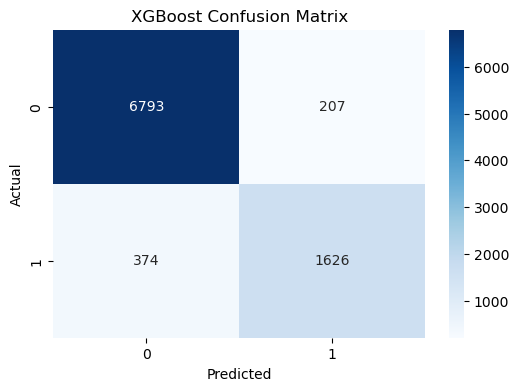

In [27]:
y_pred = xgb.predict(X_test)
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/reports/confusion_matrix_xgb.png",
    bbox_inches="tight"
)
    

plt.show()

The XGBoost model correctly classified **6,793** non-default loan applications and **1,626** default loan applications.

The model produced **207 False Positives**, where non-default applicants were incorrectly predicted as defaults, and **374 False Negatives**, where default applicants were incorrectly predicted as non-defaults.

Overall, the confusion matrix indicates strong classification performance with a high number of correct predictions and relatively few misclassifications, supporting the model's effectiveness for loan approval prediction.

## Classification Report

In [28]:
report = classification_report(
    y_test,
    y_pred,
)

with open(
    "C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/reports/classification_report.txt",
    "w"
) as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7000
           1       0.89      0.81      0.85      2000

    accuracy                           0.94      9000
   macro avg       0.92      0.89      0.90      9000
weighted avg       0.93      0.94      0.93      9000



### Save Best Model

In [19]:
joblib.dump(
    xgb,
    "C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/models/best_model.pkl"
)

['C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/models/best_model.pkl']

# Conclusion

Three machine learning models were trained and evaluated for loan approval prediction.

Among the evaluated models, XGBoost achieved the highest performance across key metrics including Accuracy, Recall, F1-Score, and ROC-AUC.

Therefore, XGBoost was selected as the final model for deployment and further MLOps implementation.